In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def compute_far_with_errorbar(statistic, lifetime=1):
    """Compute a false alarm rate histogram from a list of triggers and a lifetime.

    Parameters
    ----------
    statistic : [float]
        Array containing the detection statistic of triggers from which to compute FAR.
    lifetime : float, optional
        Duration of simulated background [s].

    Returns
    -------
    bins : [float]
        bins of p_lambda
    far : [float]
        False-alarm rate corresponding to each bin
    error: [float]
        Error bar on the FAR estimation assuming a Poisson distribution
    """
    statistic[np.where(np.isnan(statistic))] = 0.0
    n = len(statistic)
    sorted_stat = np.sort(statistic)
    cumulative_dist = np.array(range(n))
    inverse_cumulative_dist = np.max(cumulative_dist) - cumulative_dist + 1

    far = inverse_cumulative_dist / lifetime
    error = far / np.sqrt(inverse_cumulative_dist)

    return sorted_stat, far, error


In [3]:
triggers_noise = np.load('inputs/triggers_background_Gaussian_noise.npy')
triggers_MDC = np.load('inputs/triggers_background_MDC.npy')

print(len(triggers_noise))
print(len(triggers_MDC))

print(triggers_noise.dtype)
print(triggers_noise['start1'])
print(len(pd.unique(triggers_MDC['start1'])))

ValueError: Cannot load file containing pickled data when allow_pickle=False

In [6]:
livetime = np.loadtxt('inputs/lifetime_E1E2.txt')
print(livetime)

[8.638800e+04 1.382208e+08]


In [7]:
sorted_stat1, FAR1, error1 = compute_far_with_errorbar(triggers_noise['p_lambda'], livetime[1])
sorted_stat2, FAR2, error2 = compute_far_with_errorbar(triggers_MDC['p_lambda'], livetime[1])

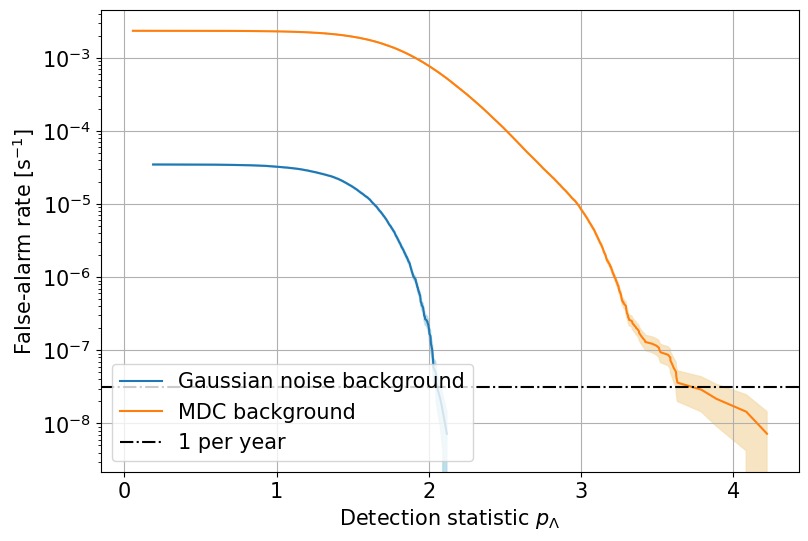

In [ ]:
plt.figure(figsize=(9,6))
ax = plt.gca()

ax.plot(sorted_stat1, FAR1, label='Gaussian noise background')
ax.fill_between(sorted_stat1, FAR1 - error1, FAR1 + error1, alpha=0.8, color="lightblue")

ax.plot(sorted_stat2, FAR2, label='MDC background')
ax.fill_between(sorted_stat2, FAR2 - error2, FAR2 + error2, alpha=0.8, color="wheat")

ax.set_xlabel(r'Detection statistic $p_\Lambda$', fontsize=15)
ax.set_ylabel(r'False-alarm rate [s$^{-1}$]', fontsize=15)
ax.tick_params(axis='both', labelsize=15)
ax.set_yscale('log')
ax.axhline(1/365.25/86400, 0, 1, color='black', ls='-.', label='1 per year')
ax.grid()
ax.legend(fontsize=15)

# plt.savefig('noise_and_MDC_FAR.svg', format = 'svg')




In [9]:
max_noise = np.max(triggers_noise['p_lambda'])
print(max_noise)

triggers_above_max = triggers_MDC[triggers_MDC['p_lambda'] > max_noise]
print(len(triggers_above_max))

# A cause des time shifts les triggers sont multipliés: pour un trigger donné on se retrouve avec plein de triggers time shiftés, donc on veut extraire les triggers uniques:
_, unique_triggers_index = np.unique(triggers_above_max['start1'], return_index=True)
unique_triggers_above_max = triggers_above_max [unique_triggers_index]
print(len(unique_triggers_above_max))

2.1184975211047496
72111
192


In [10]:
pl = unique_triggers_above_max['p_lambda']
true_pl = np.zeros_like(pl)

for i in range(len(true_pl)):
    all_triggers = np.where(triggers_above_max['start1'] == unique_triggers_above_max[i]['start1'])
    true_pl[i] = np.max(triggers_above_max['p_lambda'][all_triggers])

order = np.flip(np.argsort(true_pl))
unique_triggers_above_max = unique_triggers_above_max[order]
starts = unique_triggers_above_max['start1']
ends = unique_triggers_above_max['start1'] + unique_triggers_above_max['duration']

In [12]:
injs = np.loadtxt('/home/victor/Internship_Victor_CBC_ET/code_Adrian/MLE_pipeline/data/loudest_BBH/list_mdc1_v2.txt')
injs = injs[injs[:,-2] > 15]
order2 = np.flip(np.argsort(injs[:,-2]))
injs = injs[order2]
tc = injs[:,2]

In [13]:
def find_closest_tc(tc, t_end):
    dist = np.abs(tc - t_end)
    i_min = np.argmin(dist)
    return i_min

In [14]:
i_closest = np.zeros(len(ends), dtype=int)

for i in range(len(ends)):
    i_closest[i] = find_closest_tc(tc, ends[i])

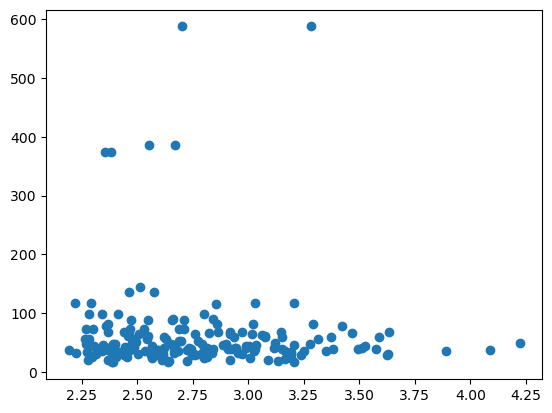

In [15]:
plt.scatter(true_pl, injs[i_closest,-2])

In [16]:
np.max(unique_triggers_above_max['p_lambda'])

3.009965414735042

In [17]:
true_pl[0]

3.2816513964944494

In [18]:
ends[1]

1001620470.0